In [1]:
!pip install torchvision seaborn tqdm

In [2]:
import torch, torchvision
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import numpy as np
import pandas as pd
import torch.utils.data as data
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
from copy import deepcopy

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # multi-GPU
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_data = pd.read_csv("/content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/train_data.csv")
train_data.head()

,SalePrice,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,141592,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0
1,51327,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
2,48672,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0
3,380530,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0
4,78318,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0


In [6]:
def get_price_range(price, budget=1e5, credit=2.5*1e5):
  "0 - cheap, 1 - average, 2 - expensive"
  if price <= budget:
    return 0
  elif price <= budget + credit:
    return 1
  return 2

y_train = train_data['SalePrice'].apply(get_price_range)
y_train.head()

,SalePrice
0,1
1,0
2,0
3,2
4,0


In [7]:
y_train.value_counts().head()

,count
SalePrice,
1,2992
2,570
0,562


In [8]:
class_counts = y_train.value_counts().sort_index().to_numpy()

In [9]:
class_weights = np.max(class_counts) / class_counts

In [10]:
class_counts, class_weights

(array([ 562, 2992,  570]), array([5.32384342, 1.        , 5.24912281]))

## Data preprocessing
Proposed changes:
* YearBuilt -> Age = 2026 - YearBuilt
* HallwayType, HeatingType, AptManageType, TimeToBusStop, TimeToSubway -> Categorical -> cat.codes
* SubwayStation -> get_dummies

In [11]:
test_data = pd.read_csv("/content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/test_data.csv")
test_data.head()

,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,1993,914,10,mixed,individual_heating,management_in_trust,523.0,536.0,0~5min,15min~20min,8.0,20.0,Myung-duk,4,14.0,17.0
1,2014,907,16,terraced,individual_heating,management_in_trust,90.0,1174.0,0~5min,0-5min,7.0,20.0,Myung-duk,9,14.0,17.0
2,2007,1629,7,terraced,individual_heating,management_in_trust,7.0,605.0,0~5min,0-5min,5.0,5.0,Banwoldang,5,9.0,5.0
3,2005,743,21,mixed,individual_heating,management_in_trust,67.0,798.0,0~5min,5min~10min,6.0,0.0,Bangoge,7,13.0,15.0
4,2006,903,7,terraced,individual_heating,management_in_trust,123.0,181.0,5min~10min,0-5min,3.0,11.0,Myung-duk,4,8.0,11.0


In [12]:
train_data['Age'] = train_data['YearBuilt'].apply(
    lambda x: 2026 - x
)
train_data = train_data.drop(columns=['SalePrice', 'YearBuilt'])
train_data.head()

,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),Age
0,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0,20
1,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,41
2,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,41
3,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0,20
4,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0,34


In [13]:
test_data['Age'] = test_data['YearBuilt'].apply(
    lambda x: 2026 - x
)
test_data = test_data.drop(columns=['YearBuilt'])

In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4124 entries, 0 to 4123
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Size(sqf)                  4124 non-null   int64  
 1   Floor                      4124 non-null   int64  
 2   HallwayType                4124 non-null   object 
 3   HeatingType                4124 non-null   object 
 4   AptManageType              4124 non-null   object 
 5   N_Parkinglot(Ground)       4124 non-null   float64
 6   N_Parkinglot(Basement)     4124 non-null   float64
 7   TimeToBusStop              4124 non-null   object 
 8   TimeToSubway               4124 non-null   object 
 9   N_manager                  4124 non-null   float64
 10  N_elevators                4124 non-null   float64
 11  SubwayStation              4124 non-null   object 
 12  N_FacilitiesInApt          4124 non-null   int64  
 13  N_FacilitiesNearBy(Total)  4124 non-null   float

In [15]:
train_data.describe()

,Size(sqf),Floor,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),Age
count,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000,4124.000000
mean,959.958778,11.994665,192.789040,572.857662,6.313773,11.055771,5.824200,9.860330,10.872696,23.022066
std,384.548456,7.581330,215.455916,408.179957,3.224556,7.717030,2.344331,3.444848,4.427445,8.765838
min,135.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,11.000000
25%,644.000000,6.000000,11.000000,184.000000,5.000000,5.000000,4.000000,8.000000,7.000000,19.000000
50%,910.000000,11.000000,100.000000,536.000000,6.000000,11.000000,5.000000,9.000000,10.000000,20.000000
75%,1160.000000,17.000000,249.000000,798.000000,8.000000,16.000000,7.000000,13.000000,15.000000,33.000000
max,2337.000000,43.000000,713.000000,1321.000000,14.000000,27.000000,10.000000,16.000000,17.000000,48.000000


In [16]:
train_data["TimeToSubway"].value_counts()

,count
TimeToSubway,
0-5min,1960
5min~10min,792
15min~20min,682
10min~15min,526
no_bus_stop_nearby,164


In [17]:
train_data['TimeToBusStop'] = pd.Categorical(train_data['TimeToBusStop'], categories=['0~5min', '5min~10min', '10min~15min'])
train_data['TimeToSubway'] = pd.Categorical(train_data['TimeToSubway'], categories=['0-5min', '5min~10min', '10min~15min', '15min~20min', "no_bus_stop_nearby"])
train_data["HeatingType"] = pd.Categorical(train_data["HeatingType"], categories=["individual_heating", "central_heating"])
train_data["AptManageType"] = pd.Categorical(train_data["AptManageType"], categories=["management_in_trust", "self_management"])
train_data["HallwayType"] = pd.Categorical(train_data["HallwayType"], categories=["terraced", "mixed", "corridor"])

In [18]:
train_data['TimeToBusStop'] = train_data['TimeToBusStop'].cat.codes
train_data['TimeToSubway'] = train_data['TimeToSubway'].cat.codes
train_data["HeatingType"] = train_data["HeatingType"].cat.codes
train_data["AptManageType"] = train_data["AptManageType"].cat.codes
train_data["HallwayType"] = train_data["HallwayType"].cat.codes

In [19]:
test_data['TimeToBusStop'] = pd.Categorical(test_data['TimeToBusStop'], categories=['0~5min', '5min~10min', '10min~15min'])
test_data['TimeToSubway'] = pd.Categorical(test_data['TimeToSubway'], categories=['0-5min', '5min~10min', '10min~15min', '15min~20min', "no_bus_stop_nearby"])
test_data["HeatingType"] = pd.Categorical(test_data["HeatingType"], categories=["individual_heating", "central_heating"])
test_data["AptManageType"] = pd.Categorical(test_data["AptManageType"], categories=["management_in_trust", "self_management"])
test_data["HallwayType"] = pd.Categorical(test_data["HallwayType"], categories=["terraced", "mixed", "corridor"])

In [20]:
test_data['TimeToBusStop'] = test_data['TimeToBusStop'].cat.codes
test_data['TimeToSubway'] = test_data['TimeToSubway'].cat.codes
test_data["HeatingType"] = test_data["HeatingType"].cat.codes
test_data["AptManageType"] = test_data["AptManageType"].cat.codes
test_data["HallwayType"] = test_data["HallwayType"].cat.codes

In [21]:
train_data["TimeToSubway"].value_counts()

,count
TimeToSubway,
0,1960
1,792
3,682
2,526
4,164


In [22]:
subway_station_values = pd.get_dummies(train_data['SubwayStation']).astype(int)
subway_station_values.head()

,Bangoge,Banwoldang,Chil-sung-market,Daegu,Kyungbuk_uni_hospital,Myung-duk,Sin-nam,no_subway_nearby
0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0


In [23]:
train_data = train_data.join(subway_station_values)

In [24]:
train_data.drop(columns="SubwayStation", inplace=True)
train_data.head()

,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,N_SchoolNearBy(Total),Age,Bangoge,Banwoldang,Chil-sung-market,Daegu,Kyungbuk_uni_hospital,Myung-duk,Sin-nam,no_subway_nearby
0,814,3,0,0,0,111.0,184.0,1,2,3.0,...,9.0,20,0,0,0,0,1,0,0,0
1,587,8,2,0,1,80.0,76.0,0,1,2.0,...,4.0,41,0,0,0,1,0,0,0,0
2,587,6,2,0,1,80.0,76.0,0,1,2.0,...,4.0,41,0,0,0,1,0,0,0,0
3,2056,8,0,0,0,249.0,536.0,0,0,5.0,...,7.0,20,0,0,0,0,0,0,1,0
4,644,2,1,0,1,142.0,79.0,1,3,4.0,...,14.0,34,0,0,0,0,0,1,0,0


In [25]:
test_data = test_data.join(pd.get_dummies(test_data['SubwayStation']).astype(int))

In [26]:
test_data.drop(columns="SubwayStation", inplace=True)
test_data.head()

,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,...,N_SchoolNearBy(Total),Age,Bangoge,Banwoldang,Chil-sung-market,Daegu,Kyungbuk_uni_hospital,Myung-duk,Sin-nam,no_subway_nearby
0,914,10,1,0,0,523.0,536.0,0,3,8.0,...,17.0,33,0,0,0,0,0,1,0,0
1,907,16,0,0,0,90.0,1174.0,0,0,7.0,...,17.0,12,0,0,0,0,0,1,0,0
2,1629,7,0,0,0,7.0,605.0,0,0,5.0,...,5.0,19,0,1,0,0,0,0,0,0
3,743,21,1,0,0,67.0,798.0,0,1,6.0,...,15.0,21,1,0,0,0,0,0,0,0
4,903,7,0,0,0,123.0,181.0,1,0,3.0,...,11.0,20,0,0,0,0,0,1,0,0


In [50]:
train_indices = np.random.rand(len(train_data))>0.3

In [28]:
from sklearn.preprocessing import StandardScaler

In [51]:
numerical_data_np = train_data.values[train_indices,:-1]
valid_numerical_data_np = train_data.values[~train_indices,:-1]

scaler = StandardScaler()
numerical_data_scaled = scaler.fit_transform(numerical_data_np)
valid_numerical_data_scaled = scaler.transform(valid_numerical_data_np)

In [52]:
test_data_scaled = scaler.transform(test_data.values[:,:-1])

In [53]:
numerical_data = torch.from_numpy(numerical_data_scaled).float()
targets = torch.from_numpy(y_train.values[train_indices]).float()

valid_numerical_data = torch.from_numpy(valid_numerical_data_scaled).float()
valid_targets = torch.from_numpy(y_train.values[~train_indices]).float()

In [54]:
train_dataset = data.TensorDataset(numerical_data, targets)
valid_dataset = data.TensorDataset(valid_numerical_data, valid_targets)

In [55]:
y_test = np.random.rand(1767)

In [56]:
test_numerical_data = torch.from_numpy(test_data_scaled).float()
test_targets = torch.from_numpy(y_test).float()

In [57]:
test_dataset = data.TensorDataset(test_numerical_data, test_targets)

In [58]:
train_dataset[0]

(tensor([-0.3690, -1.1939, -0.7328, -0.2162, -0.2526, -0.3718, -0.9561,  1.7033,
          0.7155, -1.0252, -1.4267, -0.3521, -1.1099, -0.4217, -0.3298, -0.3753,
         -0.3891, -0.1359, -0.1277,  1.6215, -0.5812, -0.3644]),
 tensor(1.))

In [59]:
print(numerical_data.shape)

torch.Size([2867, 22])


## Classifier Model

In [60]:
class PriceClassifier(nn.Module):
  def __init__(self):
    super(PriceClassifier, self).__init__()
    self.layer1 = nn.Linear(numerical_data.shape[1], 81)
    self.bn1 = nn.BatchNorm1d(81)
    self.actfn1 = nn.LeakyReLU()
    self.d1 = nn.Dropout(p=0.3)

    self.layer2 = nn.Linear(81,27)
    self.bn2 = nn.BatchNorm1d(27)
    self.actfn2 = nn.LeakyReLU()
    self.d2 = nn.Dropout(p=0.3)

    self.layer3 = nn.Linear(27, 3)
  def forward(self, x):
    x = self.actfn1(self.bn1(self.layer1(x)))
    x = self.actfn2(self.bn2(self.layer2(x)))
    x = self.layer3(x)
    return x

In [61]:
def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets == targets.values)[targets == i].sum()
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))

In [62]:
def get_preds_and_targets(model, loader):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for x, labels in loader:
            x = x.to(device)

            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            preds_list.append(preds)
            targets_list.append(labels.numpy())

    return np.concatenate(preds_list), np.concatenate(targets_list)

In [63]:
# sampler_weights = torch.tensor([class_weights[int(c)] for c in targets], device=device, dtype=torch.float)
# sampler = torch.utils.data.WeightedRandomSampler(weights=sampler_weights, num_samples=len(sampler_weights), replacement=True)
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, sampler=sampler)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=128, shuffle=False)

In [64]:
model = PriceClassifier().to(device)
num_epochs = 200
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=device, dtype=torch.float))
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)

iters = []
losses = []
train_acc = []
val_acc = []
best_acc = 0
for n in range(num_epochs):
    epoch_losses = []
    model.train()
    for x, labels in iter(train_loader):
        optimizer.zero_grad()
        x, labels = x.to(device), labels.to(device).long()
        out = model(x)
        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()
        lr_scheduler.step()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    val_preds, val_targets = get_preds_and_targets(model, valid_loader)
    train_preds, train_targets = get_preds_and_targets(model, train_loader)
    val_targets = pd.Series(val_targets)
    train_targets = pd.Series(train_targets)

    valid_acc = calc_accuracy(val_preds, val_targets)
    training_acc = calc_accuracy(train_preds, train_targets)
    train_acc.append(calc_accuracy(train_preds, train_targets))
    print(f"Epoch {n+1} loss {loss_mean:.3} lr: {lr_scheduler.get_last_lr()[0]:f} train accuracy: {training_acc} validation accuracy: {valid_acc}")
    val_acc.append(valid_acc)  # compute validation accuracy
    if valid_acc > best_acc:
        best_acc = valid_acc
        state_dict = deepcopy(model.state_dict())
        print("Saved new best")

print(f"{best_acc=}")

Epoch 1 loss 0.839 lr: 0.004989 train accuracy: 0.7673006224707395 validation accuracy: 0.7680367466539954
Saved new best
Epoch 2 loss 0.572 lr: 0.004957 train accuracy: 0.7762433977231114 validation accuracy: 0.7886214521994992
Saved new best
Epoch 3 loss 0.489 lr: 0.004903 train accuracy: 0.8088552249955369 validation accuracy: 0.8180971034420663
Saved new best
Epoch 4 loss 0.432 lr: 0.004828 train accuracy: 0.8185918526041743 validation accuracy: 0.8245618002192896
Saved new best
Epoch 5 loss 0.399 lr: 0.004733 train accuracy: 0.8360941831885941 validation accuracy: 0.85158094928925
Saved new best
Epoch 6 loss 0.37 lr: 0.004619 train accuracy: 0.8731587181717614 validation accuracy: 0.878562204353185
Saved new best
Epoch 7 loss 0.344 lr: 0.004486 train accuracy: 0.882639476056804 validation accuracy: 0.8893388673037609
Saved new best
Epoch 8 loss 0.328 lr: 0.004336 train accuracy: 0.8837914744780483 validation accuracy: 0.8904171427940107
Saved new best
Epoch 9 loss 0.315 lr: 0.0041

In [65]:
model_file = "/content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/best_original90.tar"
# torch.save(state_dict, model_file)
state_dict = torch.load(model_file)
model = PriceClassifier().to(device)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [67]:
valid_preds, valid_targets = get_preds_and_targets(model, valid_loader)
pred_tar_df = pd.DataFrame({
    'valid_preds': valid_preds,
    'valid_targets': valid_targets
})

<Axes: >

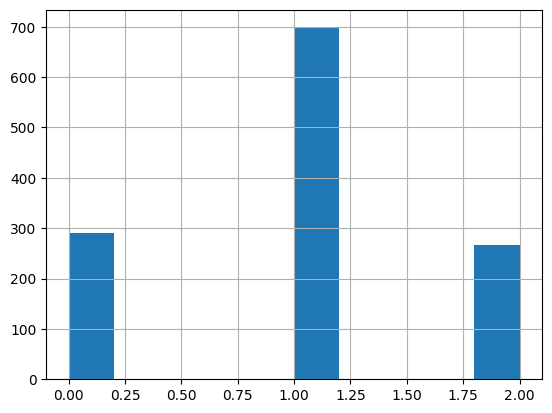

In [68]:
pred_tar_df['valid_preds'].astype(int).hist()

<Axes: >

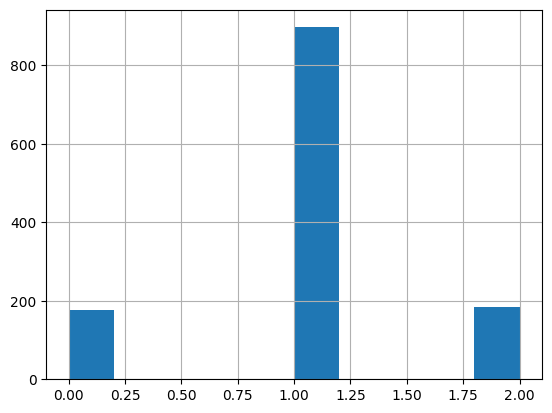

In [69]:
pred_tar_df['valid_targets'].astype(int).hist()

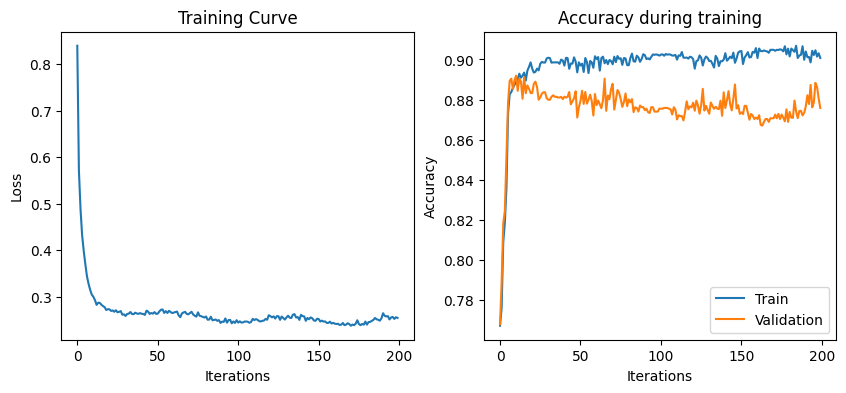

In [70]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Accuracy during training")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

In [71]:
val_preds, val_targets = get_preds_and_targets(model, valid_loader)
train_preds, train_targets = get_preds_and_targets(model, train_loader)
val_targets = pd.Series(val_targets)
train_targets = pd.Series(train_targets)

valid_acc = calc_accuracy(val_preds, val_targets)
training_acc = calc_accuracy(train_preds, train_targets)
print(f"Train accuracy: {training_acc} Validation accuracy: {valid_acc}")

Train accuracy: 0.8992305620823132 Validation accuracy: 0.9044903777619386


## Getting results for test data

In [72]:
test_data_loader = data.DataLoader(test_dataset, batch_size=1767, shuffle=False, drop_last=False)

In [73]:
model.eval()

with torch.no_grad():
    for data_inputs, data_labels in test_data_loader:
        data_inputs = data_inputs.to(device).float()
        data_labels = data_labels.to(device).float()

        outputs = model(data_inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

In [74]:
results = pd.DataFrame(preds)
results.head()

,0
0,1
1,2
2,2
3,1
4,1


In [75]:
results.describe()

,0
count,1767.000000
mean,0.963214
std,0.650206
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


In [76]:
results.value_counts()

,count
0,
1,1018
0,407
2,342


In [77]:
results.to_csv("/content/drive/MyDrive/sroda_FijalkowskiFilip_ZukowskaRadoslawa/pred.csv", index=False, header=False)